# Task 1 — Student Score Prediction

**Objectif :** prédire le score d'examen (`Exam_Score`) à partir des heures d'étude (`Hours_Studied`), avec une régression linéaire.

**Dataset :** Student Performance Factors (Kaggle) — 6607 étudiants, 20 colonnes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.rcParams["figure.figsize"] = (8, 5)

## 1. Chargement et aperçu des données

In [2]:
df = pd.read_csv("../data/StudentPerformanceFactors.csv")
print(df.shape)
df.head()

(6607, 20)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

## 2. Nettoyage des données

3 colonnes catégorielles ont des valeurs manquantes : `Teacher_Quality`, `Parental_Education_Level`, `Distance_from_Home`.
On ne les utilise pas dans le modèle principal (basé sur `Hours_Studied`), donc pas besoin de les traiter ici — mais on vérifie qu'il n'y a pas de valeurs manquantes sur les colonnes qui nous intéressent.

In [4]:
print(df.isnull().sum()[df.isnull().sum() > 0])
print()
print("Manquants sur Hours_Studied / Exam_Score :", df[["Hours_Studied", "Exam_Score"]].isnull().sum().sum())

Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64

Manquants sur Hours_Studied / Exam_Score : 0


On note aussi un score max de 101 (sur un barème apparemment /100) — probablement une valeur aberrante à surveiller, mais on la garde pour l'instant (pas suffisamment extrême pour la retirer).

In [5]:
df[["Hours_Studied", "Exam_Score"]].describe()

,Hours_Studied,Exam_Score
count,6607.000000,6607.000000
mean,19.975329,67.235659
std,5.990594,3.890456
min,1.000000,55.000000
25%,16.000000,65.000000
50%,20.000000,67.000000
75%,24.000000,69.000000
max,44.000000,101.000000


## 3. Visualisation exploratoire

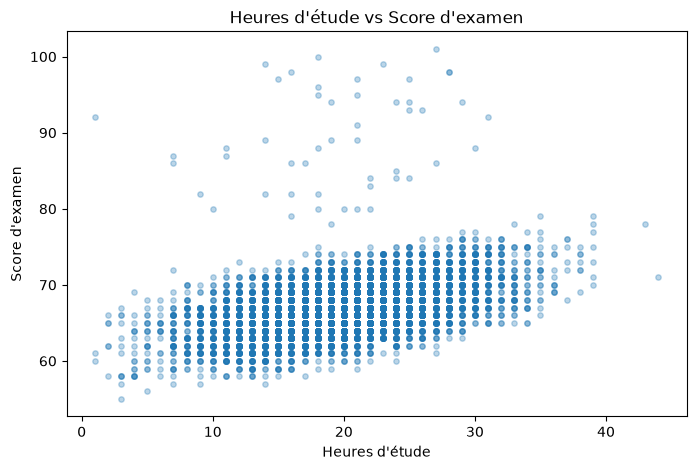

In [6]:
plt.scatter(df["Hours_Studied"], df["Exam_Score"], alpha=0.3, s=15)
plt.xlabel("Heures d'étude")
plt.ylabel("Score d'examen")
plt.title("Heures d'étude vs Score d'examen")
plt.savefig("../outputs/01_scatter_hours_vs_score.png", dpi=150, bbox_inches="tight")
plt.show()

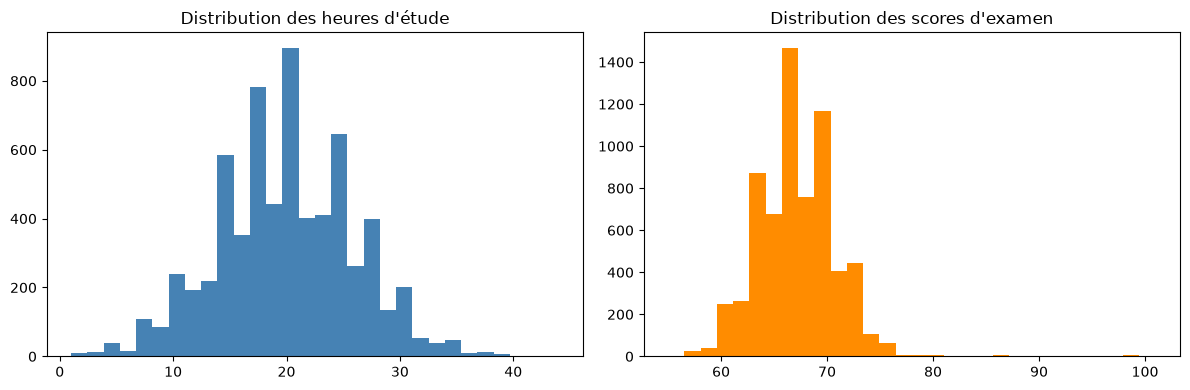

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df["Hours_Studied"], bins=30, color="steelblue")
axes[0].set_title("Distribution des heures d'étude")
axes[1].hist(df["Exam_Score"], bins=30, color="darkorange")
axes[1].set_title("Distribution des scores d'examen")
plt.tight_layout()
plt.savefig("../outputs/02_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
print("Corrélation Hours_Studied / Exam_Score :", df["Hours_Studied"].corr(df["Exam_Score"]).round(3))

Corrélation Hours_Studied / Exam_Score : 0.445


## 4. Split train/test

In [9]:
X = df[["Hours_Studied"]]
y = df["Exam_Score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (5285, 1)  Test: (1322, 1)


## 5. Régression linéaire simple

In [10]:
model = LinearRegression()
model.fit(X_train, y_train)

print(f"Coefficient (pente) : {model.coef_[0]:.3f}")
print(f"Intercept : {model.intercept_:.3f}")

Coefficient (pente) : 0.286
Intercept : 61.511


In [11]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R2   : {r2:.3f}")

MAE  : 2.448
RMSE : 3.295
R2   : 0.232


## 6. Visualisation des prédictions

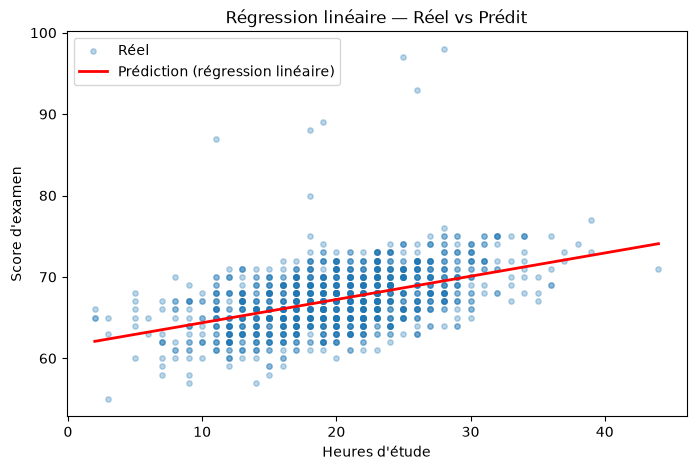

In [12]:
plt.scatter(X_test, y_test, alpha=0.3, s=15, label="Réel")
order = X_test["Hours_Studied"].argsort()
plt.plot(X_test["Hours_Studied"].values[order], y_pred[order], color="red", linewidth=2, label="Prédiction (régression linéaire)")
plt.xlabel("Heures d'étude")
plt.ylabel("Score d'examen")
plt.title("Régression linéaire — Réel vs Prédit")
plt.legend()
plt.savefig("../outputs/03_regression_line.png", dpi=150, bbox_inches="tight")
plt.show()

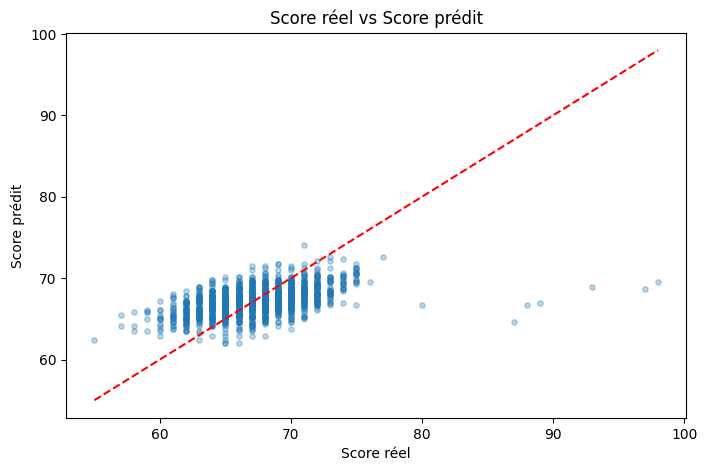

In [13]:
plt.scatter(y_test, y_pred, alpha=0.3, s=15)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red", linestyle="--")
plt.xlabel("Score réel")
plt.ylabel("Score prédit")
plt.title("Score réel vs Score prédit")
plt.savefig("../outputs/04_actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Régression polynomiale

In [13]:
results = {}

for degree in [1, 2, 3]:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    m = LinearRegression()
    m.fit(X_train_poly, y_train)
    pred = m.predict(X_test_poly)

    results[degree] = {
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2": r2_score(y_test, pred),
    }

pd.DataFrame(results).T

,MAE,RMSE,R2
1,2.447569,3.294833,0.231987
2,2.444780,3.293173,0.232760
3,2.444512,3.292998,0.232842


→ R² ne s'améliore pas avec le degré, c'est le signe que la relation Heures d'étude / Score est déjà bien captée de façon linéaire — pas besoin de complexifier le modèle.

## 8. Ajout d'autres features (sommeil, participation...)

In [14]:
features = ["Hours_Studied", "Sleep_Hours", "Previous_Scores", "Tutoring_Sessions", "Physical_Activity"]
X_multi = df[features]
y_multi = df["Exam_Score"]

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)
pred_multi = model_multi.predict(X_test_m)

print("MAE  :", round(mean_absolute_error(y_test_m, pred_multi), 3))
print("RMSE :", round(np.sqrt(mean_squared_error(y_test_m, pred_multi)), 3))
print("R2   :", round(r2_score(y_test_m, pred_multi), 3))
print()
for feat, coef in zip(features, model_multi.coef_):
    print(f"{feat:20s} : {coef:+.3f}")

MAE  : 2.343
RMSE : 3.202
R2   : 0.275

Hours_Studied        : +0.286
Sleep_Hours          : -0.076
Previous_Scores      : +0.046
Tutoring_Sessions    : +0.530
Physical_Activity    : +0.111


→ `Previous_Scores` (score précédent) est probablement le feature le plus prédictif après `Hours_Studied` — logique, un bon élève reste généralement performant.

**Prochaines étapes possibles :** encoder les variables catégorielles (`Parental_Involvement`, `Motivation_Level`, etc.) pour un modèle encore plus complet.